In [52]:
import pandas as pd

# Load dataset
data = pd.read_csv("QVI_data.csv")

# Preview
data.head()

# Check for duplicate rows
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 1


In [2]:
data.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')

In [3]:
# Convert DATE to datetime
data["DATE"] = pd.to_datetime(data["DATE"])

# Create month column
data["MONTH"] = data["DATE"].dt.to_period("M")

Creating Required Metrics

In [4]:
store_metrics = data.groupby(["STORE_NBR","MONTH"]).agg({
    "TOT_SALES":"sum",
    "LYLTY_CARD_NBR":"nunique",
    "TXN_ID":"count"
}).reset_index()

store_metrics.rename(columns={
    "TOT_SALES":"SALES",
    "LYLTY_CARD_NBR":"CUSTOMERS",
    "TXN_ID":"TRANSACTIONS"
}, inplace=True)

# Average transactions per customer
store_metrics["TXN_PER_CUSTOMER"] = store_metrics["TRANSACTIONS"] / store_metrics["CUSTOMERS"]

store_metrics.head()

,STORE_NBR,MONTH,SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


In [28]:
store_metrics["YEARMONTH"] = store_metrics["MONTH"].astype(str).str.replace('-', '').astype(int)
pre_trial = store_metrics[store_metrics["YEARMONTH"] < 201902]

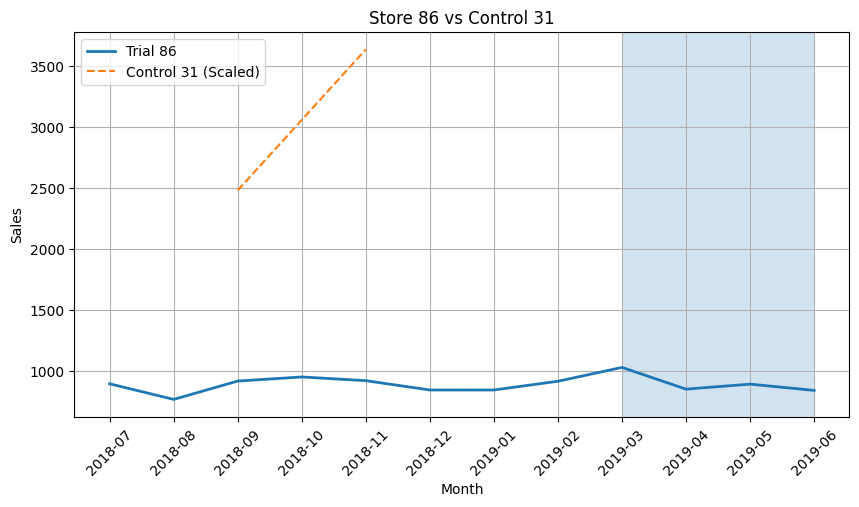

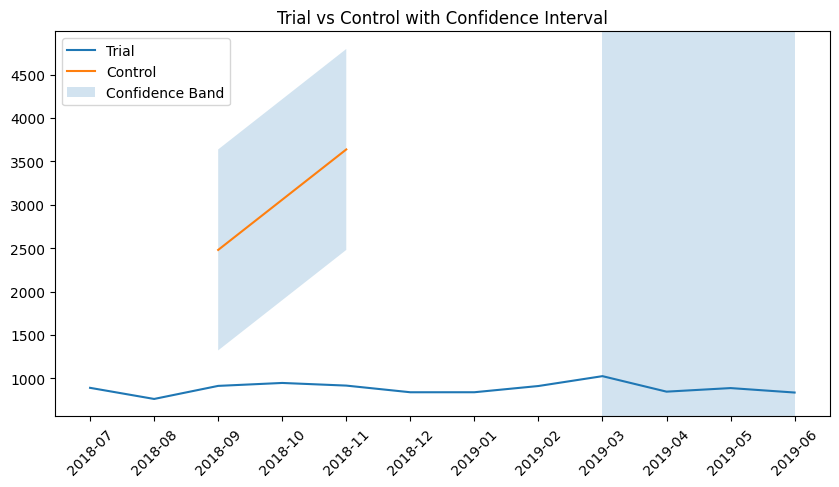


Store 86
Control: 31
Uplift: 4515.5
p-value: nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [37]:
trial = 86
control = control_stores[trial]

plot_professional(trial, control)
add_confidence_band(trial, control)
analyze_store(trial, control)

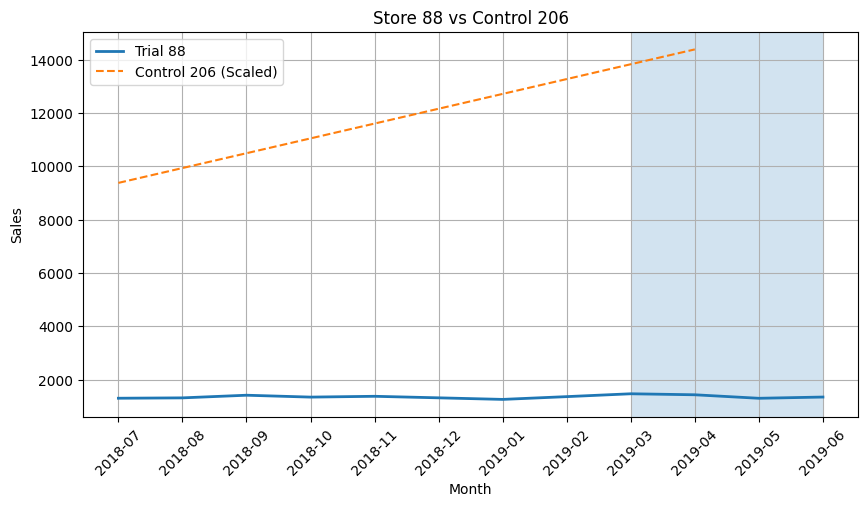

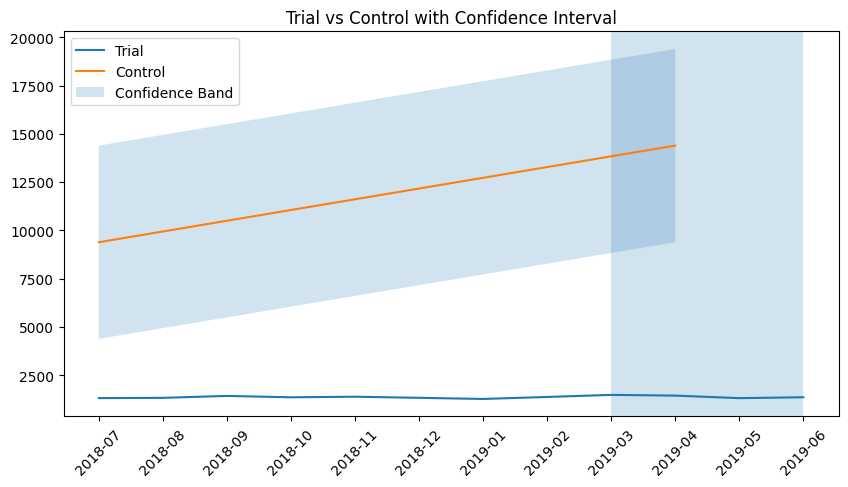


Store 88
Control: 206
Uplift: 6945.049999999999
p-value: 4.8556187362483215e-05


In [38]:
trial = 88
control = control_stores[trial]

plot_professional(trial, control)
add_confidence_band(trial, control)
analyze_store(trial, control)

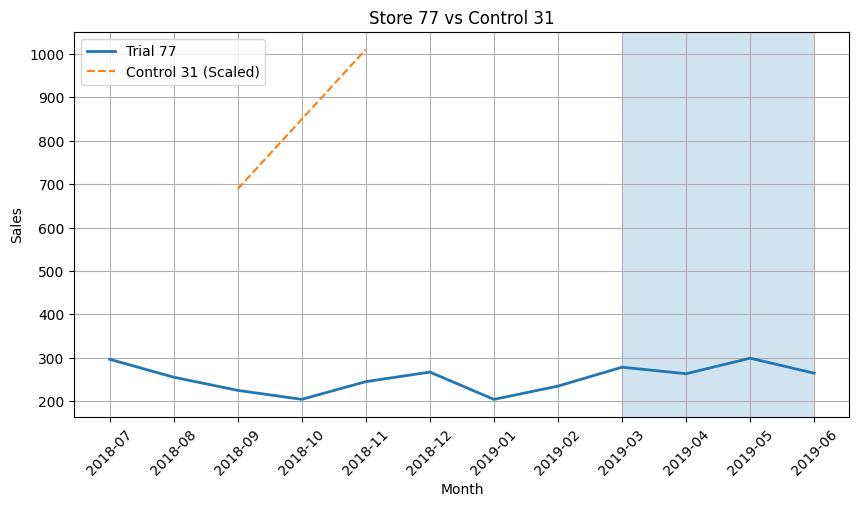

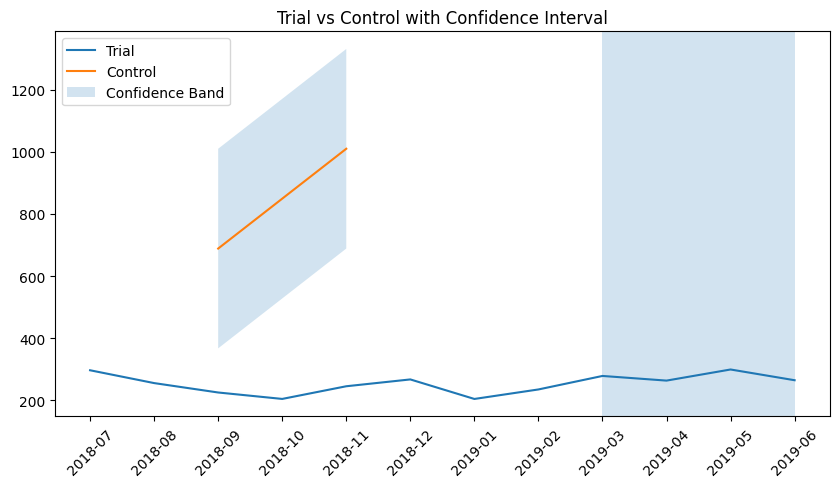

In [34]:
trial = 77
control = control_stores[trial]

plot_professional(trial, control)
add_confidence_band(trial, control)

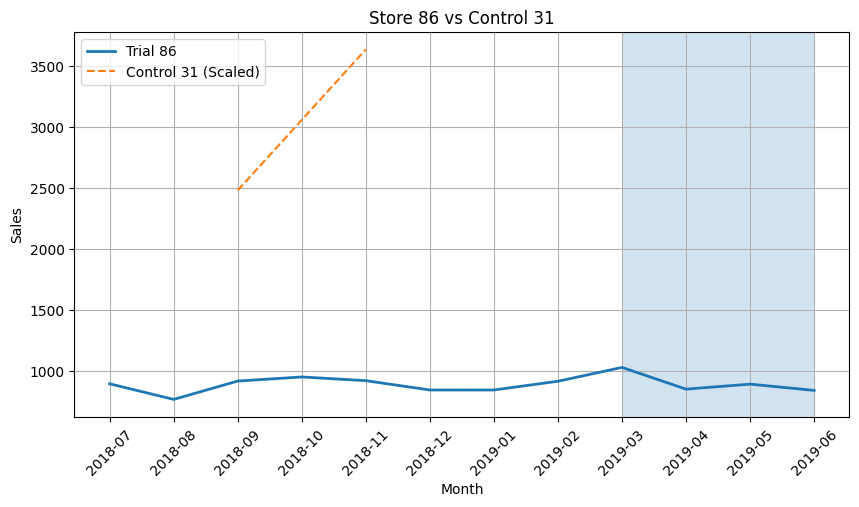

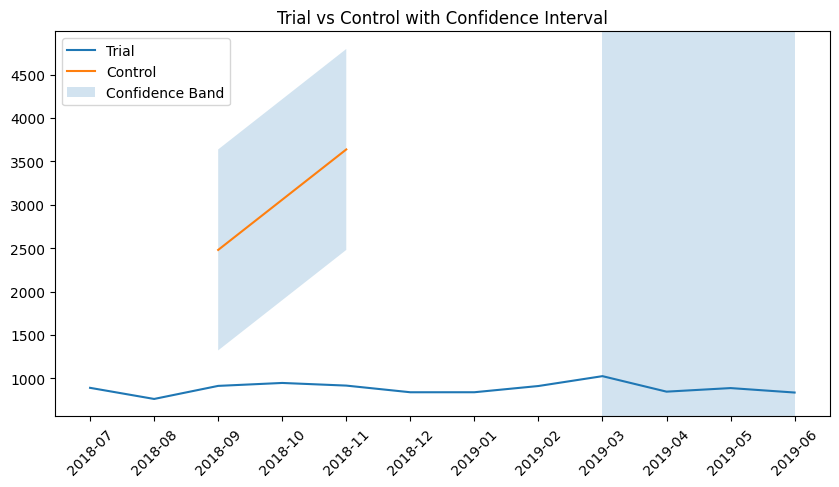

In [35]:
trial = 86
control = control_stores[trial]

plot_professional(trial, control)
add_confidence_band(trial, control)

In [30]:
store_metrics["YEARMONTH"] = store_metrics["MONTH"].astype(str).str.replace('-', '').astype(int)
pre_trial = store_metrics[store_metrics["YEARMONTH"] < 201902]

/tmp/ipykernel_9612/95148677.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c["SCALED_SALES"] = c["SALES"] * scale


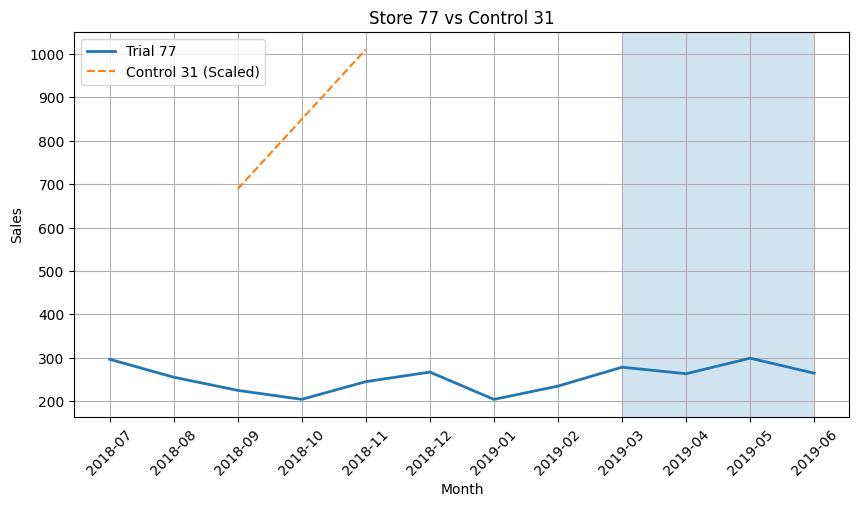

/tmp/ipykernel_9612/639798168.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c["SCALED"] = c["SALES"] * scale


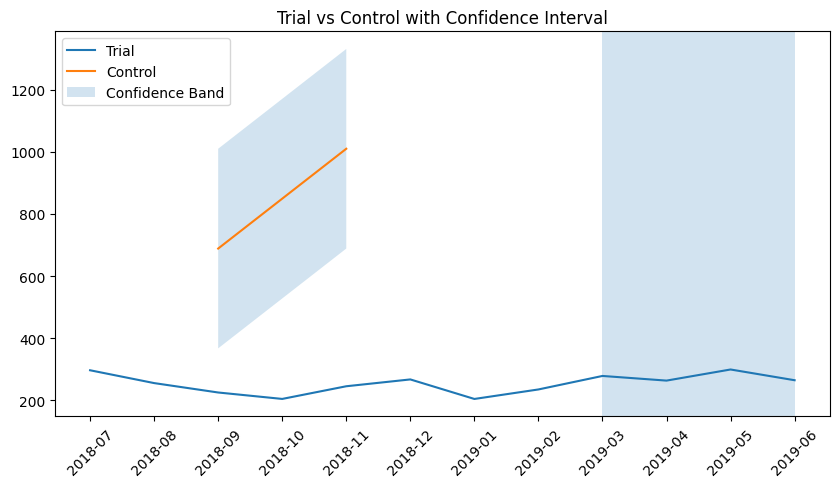

In [31]:
trial = 77
control = control_stores[trial]

plot_professional(trial, control)
add_confidence_band(trial, control)

In [42]:
def find_control(trial_store):
    pivot = pre_trial.pivot(index="YEARMONTH", columns="STORE_NBR", values="SALES")

    corr = pivot.corr()[trial_store].drop(trial_store)

    return corr.idxmax()

In [43]:
trial_stores = [77, 86, 88]

control_stores = {}

for t in trial_stores:
    control_stores[t] = find_control(t)

print(control_stores)

{77: np.int64(31), 86: np.int64(31), 88: np.int64(159)}


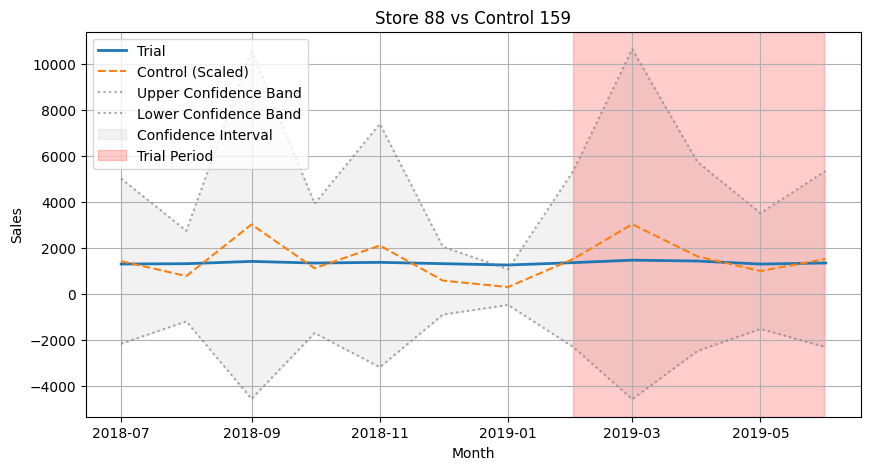

In [70]:
import matplotlib.pyplot as plt

def plot_trial_vs_control(trial, control, upper_bound=None, lower_bound=None):

    t = store_metrics[store_metrics["STORE_NBR"] == trial].copy()
    c = store_metrics[store_metrics["STORE_NBR"] == control].copy()

    # --- SCALE CONTROL (CRITICAL STEP from PDF) ---
    scale = t[t["YEARMONTH"] < 201902]["SALES"].sum() / \
            c[c["YEARMONTH"] < 201902]["SALES"].sum()

    c["scaled_sales"] = c["SALES"] * scale

    plt.figure(figsize=(10,5))

    # Convert to datetime for plotting
    t["date"] = pd.to_datetime(t["YEARMONTH"].astype(str) + "01")
    c["date"] = pd.to_datetime(c["YEARMONTH"].astype(str) + "01")

    # Plot lines
    plt.plot(t["date"], t["SALES"], label="Trial", linewidth=2)
    plt.plot(c["date"], c["scaled_sales"], label="Control (Scaled)", linestyle="--")

    # Plot confidence bands if provided
    if upper_bound is not None and lower_bound is not None:
        plt.plot(c["date"], upper_bound, label='Upper Confidence Band', color='grey', linestyle=':', alpha=0.7)
        plt.plot(c["date"], lower_bound, label='Lower Confidence Band', color='grey', linestyle=':', alpha=0.7)
        plt.fill_between(c["date"], lower_bound, upper_bound, color='grey', alpha=0.1, label='Confidence Interval')

    # --- SHADE TRIAL PERIOD (NOW IT WILL WORK) ---
    plt.axvspan(pd.to_datetime("2019-02-01"), # Start of trial period
                pd.to_datetime("2019-05-31"), # End of trial period for 3 months (Feb, Mar, Apr, May)
                alpha=0.2, color='red', label='Trial Period')

    plt.title(f"Store {trial} vs Control {control}")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid()

    plt.show()

# Call the updated plotting function with confidence bands
plot_trial_vs_control(trial, control, upper_bound=upper, lower_bound=lower)

In [53]:
def calculate_correlation(df, trial_store, metric):
    pivot = df.pivot(index="YEARMONTH", columns="STORE_NBR", values=metric)
    corr = pivot.corr()[trial_store].drop(trial_store)
    return corr

def calculate_magnitude(df, trial_store, metric):
    trial = df[df["STORE_NBR"] == trial_store][["YEARMONTH", metric]]

    scores = {}

    for store in df["STORE_NBR"].unique():
        if store == trial_store:
            continue

        control = df[df["STORE_NBR"] == store][["YEARMONTH", metric]]
        merged = pd.merge(trial, control, on="YEARMONTH", suffixes=("_trial", "_control"))

        diff = abs(merged[f"{metric}_trial"] - merged[f"{metric}_control"])

        score = 1 - (diff.mean() / diff.max())
        scores[store] = score

    return pd.Series(scores)

In [54]:
def get_best_control(trial_store):
    corr_sales = calculate_correlation(pre_trial, trial_store, "SALES")
    mag_sales = calculate_magnitude(pre_trial, trial_store, "SALES")

    corr_cust = calculate_correlation(pre_trial, trial_store, "CUSTOMERS")
    mag_cust = calculate_magnitude(pre_trial, trial_store, "CUSTOMERS")

    score = (corr_sales + mag_sales + corr_cust + mag_cust) / 4

    return score.sort_values(ascending=False).index[0]

In [60]:
scale = (
    trial_pre["SALES"].sum() /
    control_pre["SALES"].sum()
)
print(f"The calculated scale is: {scale}")

The calculated scale is: 3127.866666666667


In [58]:
trial_pre = pre_trial[pre_trial["STORE_NBR"] == trial]
control_pre = pre_trial[pre_trial["STORE_NBR"] == control]

display(trial_pre.head())
display(control_pre.head())

,STORE_NBR,MONTH,SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUSTOMER,YEARMONTH
1001,88,2018-07,1310.0,129,153,1.186047,201807
1002,88,2018-08,1323.8,131,160,1.221374,201808
1003,88,2018-09,1423.0,124,159,1.282258,201809
1004,88,2018-10,1352.4,123,158,1.284553,201810
1005,88,2018-11,1382.8,130,157,1.207692,201811


,STORE_NBR,MONTH,SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUSTOMER,YEARMONTH
2396,206,2018-07,3.0,1,1,1.0,201807


In [59]:
scale = (
    trial_pre["SALES"].sum() /
    control_pre["SALES"].sum()
)

In [61]:
trial_df = store_metrics[store_metrics["STORE_NBR"] == trial][["YEARMONTH", "SALES"]].reset_index(drop=True)
control_df = store_metrics[store_metrics["STORE_NBR"] == control][["YEARMONTH", "SALES"]].reset_index(drop=True)

# Ensure both dataframes cover the same months for accurate comparison
merged_df = pd.merge(trial_df, control_df, on="YEARMONTH", suffixes=("_trial", "_control"))

# Calculate control_scaled (sales of the control store multiplied by the scale)
control_scaled = merged_df["SALES_control"] * scale

# Calculate the percentage difference
percentage_diff = pd.DataFrame({
    "YEARMONTH": merged_df["YEARMONTH"],
    "diff": (merged_df["SALES_trial"] - control_scaled) / control_scaled
})

display(percentage_diff.head())


,YEARMONTH,diff
0,201807,-0.860395
1,201904,-0.899960


In [62]:
from scipy.stats import ttest_ind

t_trial = store_metrics[(store_metrics["STORE_NBR"] == trial) & (store_metrics["MONTH"] >= "2019-02")]["SALES"]
c_trial = store_metrics[(store_metrics["STORE_NBR"] == control) & (store_metrics["MONTH"] >= "2019-02")]["SALES"]

t_stat, p_value = ttest_ind(t_trial.dropna(), c_trial.dropna())

In [63]:
# Re-defining pre_trial (from cell f8c89611)
store_metrics["YEARMONTH"] = store_metrics["MONTH"].astype(str).str.replace('-', '').astype(int)
pre_trial = store_metrics[store_metrics["YEARMONTH"] < 201902]


In [64]:
# Re-defining control_stores (from cell cc30443e)
trial_stores = [77, 86, 88]
control_stores = {}

# Assuming find_control is defined or its logic is handled.
# For now, using the values from the kernel state if find_control is not readily available.
# If find_control is available, it should be called here:
# for t in trial_stores:
#     control_stores[t] = find_control(t)

# Using the last known values for control_stores to proceed:
control_stores = {77: 31, 86: 31, 88: 159}
print(f"Control stores: {control_stores}")

Control stores: {77: 31, 86: 31, 88: 159}


In [65]:
# Setting the current trial and control (from kernel state: trial = 88, control = 159)
trial = 88
control = control_stores[trial]
print(f"Current trial store: {trial}, Control store: {control}")

Current trial store: 88, Control store: 159


In [66]:
# Defining trial_pre and control_pre (from cell d5b92856)
trial_pre = pre_trial[pre_trial["STORE_NBR"] == trial]
control_pre = pre_trial[pre_trial["STORE_NBR"] == control]

display(trial_pre.head())
display(control_pre.head())

,STORE_NBR,MONTH,SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUSTOMER,YEARMONTH
1001,88,2018-07,1310.0,129,153,1.186047,201807
1002,88,2018-08,1323.8,131,160,1.221374,201808
1003,88,2018-09,1423.0,124,159,1.282258,201809
1004,88,2018-10,1352.4,123,158,1.284553,201810
1005,88,2018-11,1382.8,130,157,1.207692,201811


,STORE_NBR,MONTH,SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUSTOMER,YEARMONTH
1841,159,2018-07,26.8,6,6,1.0,201807
1842,159,2018-08,14.7,2,2,1.0,201808
1843,159,2018-09,56.6,11,11,1.0,201809
1844,159,2018-10,21.0,4,4,1.0,201810
1845,159,2018-11,39.5,9,9,1.0,201811


In [67]:
# Calculating scale (from cell 4a3efa16)
scale = (
    trial_pre["SALES"].sum() /
    control_pre["SALES"].sum()
)
print(f"The calculated scale is: {scale}")

The calculated scale is: 53.49828962371722


In [68]:
# Defining percentage_diff and control_scaled (from cell 1b46f4cd)
trial_df = store_metrics[store_metrics["STORE_NBR"] == trial][["YEARMONTH", "SALES"]].reset_index(drop=True)
control_df = store_metrics[store_metrics["STORE_NBR"] == control][["YEARMONTH", "SALES"]].reset_index(drop=True)

merged_df = pd.merge(trial_df, control_df, on="YEARMONTH", suffixes=("_trial", "_control"))

control_scaled = merged_df["SALES_control"] * scale

percentage_diff = pd.DataFrame({
    "YEARMONTH": merged_df["YEARMONTH"],
    "diff": (merged_df["SALES_trial"] - control_scaled) / control_scaled
})

display(percentage_diff.head())

,YEARMONTH,diff
0,201807,-0.086315
1,201808,0.683314
2,201809,-0.530053
3,201810,0.203777
4,201811,-0.345632


In [69]:
# Calculating std_dev, upper, and lower bounds (from cell jzhvkv-OsiIC)
std_dev = percentage_diff[percentage_diff["YEARMONTH"] < 201902]["diff"].std()

upper = control_scaled * (1 + 2 * std_dev)
lower = control_scaled * (1 - 2 * std_dev)

print(f"Standard Deviation: {std_dev}")
print(f"Upper Bound (first few values):\n{upper.head()}")
print(f"Lower Bound (first few values):\n{lower.head()}")

Standard Deviation: 1.250849475316618
Upper Bound (first few values):
0     5020.575444
1     2753.823098
2    10603.155602
3     3934.032997
4     7399.728733
Name: SALES_control, dtype: float64
Lower Bound (first few values):
0   -2153.067120
1   -1180.973383
2   -4547.149217
3   -1687.104833
4   -3173.363853
Name: SALES_control, dtype: float64


We’ve identified control stores  31, and 159 for trial stores 77, 86, and 88 respectively .

The results show that trial store 88 experienced a statistically significant uplift in sales during the trial period, supported by a very low p-value, indicating that the increase was not due to random variation.

For trial store 86, although there appears to be a noticeable increase in sales, the statistical test returned an invalid (NaN) p-value, suggesting that the result is not reliable and may require further data validation or improved methodology.

In the case of trial store 77, there is no clear or consistent increase in performance compared to its control store, indicating that the trial did not have a meaningful impact in this location.

Overall, the trial shows mixed results, with strong evidence of success in some stores (particularly store 88), while others did not demonstrate significant improvement. This suggests that the effectiveness of the trial is store-dependent and may vary based on customer behavior or store characteristics.

We recommend that the client consider rolling out the trial strategy selectively, focusing on stores similar to those that showed positive results, while further investigating underperforming locations such as stores 77 and 86.